# 第45课 · 给声音拍一张 X 光片——声谱图（spectrogram）：从 |STFT|² 到 dB 热力图

**目标**：把 STFT 复数矩阵真正翻译成一张能读懂的“X 光片”——幅度、功率和 dB 热力图。

> **显示工程**：$10\log_{10}$ 管功率，$20\log_{10}$ 管幅度（勿混）；`log` 前加 $\varepsilon$ 防 log0。接 L03 读图、L44 的 STFT。

🔗 Aurora 连接：[`aurora.audio.stft.magnitude_spectrogram()`](../../src/aurora/audio/stft.py) · [`aurora.audio.mel.power_to_db()`](../../src/aurora/audio/mel.py)

← **上一课**　[L44 · 亲手写 STFT](L44_stft_implement.ipynb)

> 上节课学习了 **亲手写 STFT**：分帧（framing） + 加窗 + FFT，与 aurora.audio.stft 对齐验证。  
> 本课将探讨 **声谱图生成**。

## 本课剧情：为什么声谱图看起来像"音乐的 X 光"？

医生用 X 光看骨骼——时间是横轴，身体部位是纵轴，亮度是密度。声谱图做的是一样的事：横轴是时间，纵轴是频率，亮度是能量。

STFT 输出的是复数矩阵 `S`（形状 `(n_frames, n_fft//2+1)`），每个元素携带幅度和相位。人耳感知的不是相位，而是**能量**——所以我们丢掉相位，只保留幅度：

```
mag = |S|           # 幅度谱（magnitude spectrum），单位：任意
pow = |S|²          # 功率谱（power spectrum），单位：watts
dB  = 10·log₁₀(pow + ε)  # dB 谱，压缩动态范围
```

为什么要取 dB？声音的动态范围高达 120 dB（比值 10¹²）。用线性尺度画图，轻声几乎不可见；用 dB 尺度，弱音和强音都清晰可辨——这正是人耳的对数感知方式。

**读声谱图的三个坐标**：

| 轴 | 含义 | 计算方式 |
|---|---|---|
| 横轴（时间） | 第 m 帧对应 `t = m·hop/sr` 秒 | `t = np.arange(n_frames) * hop / sr` |
| 纵轴（频率） | 第 k bin 对应 `f = k·sr/n_fft` Hz | `f = np.arange(n_fft//2+1) * sr / n_fft` |
| 颜色（亮度） | dB 功率，通常 -80~0 dB 归一化 | `dB = 10·log₁₀(|S|² + 1e-9)` |

本节任务：实现 `plot_spectrogram(x, sr, win_len, hop)` — 把信号画成 dB 幅度频谱图。

## Shape 备忘口诀（对齐 L50 MFCC 流水线）

固定约定：`1 秒 @ 16 kHz`，`win_len=512`，`hop=256`，`center=True`：

```text
STFT 复数谱     ≈ (63, 257)    # 时间 × 频率 bin
STFT 幅度/power ≈ (63, 257)
Mel 谱          ≈ (63, 40)
MFCC            ≈ (63, 13)
```

后三行在 L46–L50 逐课落地；本课先记住 **声谱图 = |STFT|² 的可视化**。


In [1]:
# Aurora matplotlib bootstrap
from pathlib import Path
import sys

_root = None
_cwd = Path.cwd().resolve()
for _candidate in (_cwd, *_cwd.parents):
    if (_candidate / '_matplotlib_bootstrap.py').exists():
        _root = _candidate
        break
if _root is None:
    _notebooks_dir = _cwd / 'notebooks'
    if _notebooks_dir.exists():
        for _found in _notebooks_dir.rglob('_matplotlib_bootstrap.py'):
            _root = _found.parent
            break
if _root is not None and str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from _matplotlib_bootstrap import apply as _aurora_mpl_apply
_aurora_mpl_apply()


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from aurora.audio.io import sine, read_wav
from aurora.audio.stft import stft, magnitude_spectrogram
from aurora.audio.mel import power_to_db

### 时间轴计算中的单位约化：为什么 (样本数) / (样本/秒) = 秒？

STFT 分帧时，第 m 帧的**起始样本位置**是 `m * hop_length`（第 0 帧从样本 0 开始，第 1 帧从样本 `hop` 开始，以此类推）。

但声谱图的横轴需要显示**秒数**，不是样本数。所以要用采样率 `sr` 进行单位转换：

$$t = \frac{m \cdot \text{hop\_length}}{sr} \quad [\text{秒}]$$

**单位检验**（关键！）：
- 分子：`m * hop_length` 的单位是"样本数" = "样本个数"
- 分母：`sr` 的定义是"每秒钟的样本数" = $\frac{\text{样本}}{\text{秒}}$
- 相除：$\frac{\text{样本数}}{\text{样本}/\text{秒}} = \text{样本数} \times \frac{\text{秒}}{\text{样本}} = \text{秒}$ ✓

**具体例子**：
- `sr = 16000` 样本/秒，`hop = 256` 样本，第 5 帧（m=5）
- 起始样本：`5 * 256 = 1280` 样本
- 转换为秒：`1280 / 16000 = 0.08` 秒
- 验证：`0.08 秒 × 16000 样本/秒 = 1280 样本` ✓（换回去确实是 1280）

这种单位转换在物理计算中很常见。下一个 Code Cell 会用这个公式计算时间轴刻度。

### 声学里"功率"是什么？为什么 |S|² 能代表功率？

在物理学中，**功率 = 单位时间做的功**，单位是瓦（W）。对于声波：

$$P_{\text{声}} = \frac{1}{2} \cdot \rho \cdot c \cdot v^2$$

其中 $\rho$ 是介质密度，$c$ 是声速，$v$ 是振幅（速度）。关键观察：**功率正比于振幅的平方** $v^2$。

在信号处理中，我们通常不关心绝对的物理瓦数（因为信号早已被模数转换成 -1 到 1 的无量纲数字），而是关心**相对能量**。所以约定俗成地定义：

$$\text{功率谱} = |\text{振幅}|^2$$

这样做的好处是：
- **能量守恒**（Parseval 定理）：时域和频域的总能量相等
- **与物理一致**：跟物理中功率∝振幅²的关系对应
- **对数尺度友好**：$\log(A^2) = 2\log(A)$，便于转 dB

所以虽然代码里只是 `A**2`，但这种平方操作体现了声学的物理原理，不是任意的数学变换。

### 为什么 STFT 输出复数，不直接给幅度？

STFT 的每个 bin 是一个**复数** $S[m, k] = A[m,k] \cdot e^{i\phi[m,k]}$，由幅度 $A$ 和相位 $\phi$ 组成。

- **相位**在频域分析中至关重要：它记录该频率成分在时域中的延迟。例如，两个 440 Hz 的纯音，如果相位相同就会叠加得更强，相位相反就会相消。这对音频处理（如回声消除、空间音频）非常重要。
- **但听觉感知呢？**人耳对相位的感知远弱于对幅度（能量）的感知。声谱图的目的是"看音乐的能量分布"，所以我们保留幅度，丢弃相位——这不是浪费，而是**针对性地提取人耳关心的信息**。

换个比喻：如果 STFT 是医学图像（CT 扫描器输出原始数据），那么光保存幅度就像只保存骨骼密度信息、丢弃了器官位置——对某些应用（如骨质疏松检查）这够用，对其他应用（如手术规划）则不够。声谱图恰好属于"只需要能量"的应用。

## 概念 1：幅度谱、功率谱、dB 谱

STFT 矩阵 `S` 形状为 `(n_frames, n_fft//2+1)`，每个元素是复数。

- **幅度谱**：`A = np.abs(S)`，单位是线性振幅
- **功率谱**：`P = A**2`，与能量正比
- **dB 谱**：`dB = 10 * log10(P + eps)`，eps 防 log(0)

Aurora 实现使用 eps = `1e-10`（对应 -100 dB 噪声底），并支持 `top_db` 截断防止动态范围过大。
注意：音频领域常见的另一种写法 `20 * log10(A + eps)` 与 `10 * log10(A**2 + eps)` 等价（仅在 eps 处有微小差异）。

### 为什么 STFT 能表示的最高频率恰好是 sr/2？（采样定理速览）

想象你在给一个飞速旋转的电风扇拍照。如果相机每秒只拍 10 张照片，风扇也刚好每秒转 10 圈，那么每次快门按下时，扇叶都停在几乎同一个位置——照片里看到的是"风扇几乎不动"，完全看不出它在高速旋转。这其实是电影和电视里常见的"车轮倒转错觉"：拍摄的采样速度跟不上物体真实的变化速度，眼睛就会被"骗"，把快速的振动看成缓慢的、甚至方向相反的振动。

声音的采样是同一回事。麦克风每秒采集 `sr` 个样本，相当于每秒给声波拍 `sr` 张"照片"。一个频率为 `f` 的纯音，每秒振动 `f` 次；要想从这些采样点里正确"认出"它是在上下振荡（而不是一条几乎不变的直线，或是一个更慢的假波形），至少需要在每个振动周期里抓到 2 个样本——一个靠近波峰，一个靠近波谷。这个"每周期至少 2 个采样点"的门槛，就是**奈奎斯特–香农采样定理**的核心结论：采样率为 `sr` 时，能够被无歧义还原的最高频率是

$$f_{\max} = \frac{sr}{2}$$

这正是"奈奎斯特频率"。如果原始信号里混有高于 `sr/2` 的成分，采样之后它们不会凭空消失，而是会"伪装"成某个低于 `sr/2` 的频率出现在结果里——这种现象叫**混叠（aliasing）**，电风扇拍照错觉正是混叠最直观的例子（想深入了解，可以回顾 L34 关于混叠的课程）。所以 STFT（以及任何基于采样数据的频谱分析）能看到的频率范围，硬性上限就是 `[0, sr/2]`——这不是某个函数参数设置的结果，而是"采样"这件事本身带来的数学极限。想看到更高的频率，唯一的办法是提高采样率 `sr`，调整 `n_fft` 或 `hop` 都无济于事。

### ε（噪声底）的选择：为什么用 1e-10 和 1e-8？

**问题**：$\log(0)$ 是负无穷，直接求 dB 会崩溃。所以加上一个小的 ε：

$$\text{dB} = 10 \log_{10}(P + \varepsilon) \quad \text{或} \quad 20 \log_{10}(A + \varepsilon)$$

**ε 的物理意义**：它定义了图中最暗部分（完全无信号时）对应的 dB 值，通常称为"噪声底"。

**为什么不同的 ε？**

- 功率形式（`ε = 1e-10`）：$10 \log_{10}(1e-10) = 10 \times (-10) = -100 \text{ dB}$
- 振幅形式（`ε = 1e-8`）：$20 \log_{10}(1e-8) = 20 \times (-8) = -160 \text{ dB}$

看起来不同，但回忆 $\log(A^2) = 2\log(A)$，当 $A = 1e-8$ 时：

$$10 \log_{10}(A^2 + 1e-10) \approx 10 \log_{10}((1e-8)^2) = 10 \log_{10}(1e-16) = -160 \text{ dB}$$

所以两个 ε 搭配的 dB 底线是一样的！

**如何选择 ε？**

实践建议：
1. **ε 太小**（如 1e-15）→ 噪声底很低，静音区域也会有杂色，图显得"脏"
2. **ε 太大**（如 1e-3）→ 噪声底很高，弱音被压成一团黑色，细节丢失
3. **合理范围**：对于 16-bit 音频（动态范围约 96 dB），ε 在 $10^{-8}$ 到 $10^{-10}$ 之间，对应噪声底 -160 dB 到 -100 dB，都是合理的

**实际测试**：下面代码对比不同 ε 的效果。

### "为什么是 10 倍和 20 倍？"——dB 公式的来源

dB（分贝）是一个对数比值单位。定义有两种形式，对应两种参考量：

**形式 1：基于功率** $\text{dB}_{\text{power}} = 10 \log_{10}(P / P_{\text{ref}})$

在声学中，功率参考通常取 $P_{\text{ref}} = 10^{-12}$ W（人耳最小可听功率）。如果用相对能量 $P = |S|^2$：

$$\text{dB}_{\text{power}} = 10 \log_{10}(|S|^2 + \varepsilon)$$

**形式 2：基于振幅** $\text{dB}_{\text{amp}} = 20 \log_{10}(A / A_{\text{ref}})$

因为功率∝振幅²，有 $A^2 = P$，所以：

$$\text{dB}_{\text{amp}} = 20 \log_{10}(A + \varepsilon) = 20 \log_{10}(|S| + \varepsilon)$$

推导过程：$10 \log_{10}(A^2) = 10 \cdot 2 \log_{10}(A) = 20 \log_{10}(A)$

**两种形式何时等价？**

当 $|S| \gg \varepsilon$ 时（信号远大于噪声底），两式近似相等。但在 $|S| \approx \varepsilon$ 附近，加法会破坏对数性质：

- $10 \log_{10}(A^2 + \varepsilon_1)$ vs $20 \log_{10}(A + \varepsilon_2)$：当 $A$ 很小时，前者的 $\varepsilon_1$ 和后者的 $\varepsilon_2$ 会导致不同的"噪声底"

**为什么不是 5 倍或 30 倍？**

因为 dB 的定义来自物理（功率比的对数），不是任意选择。一旦选定参考量和功率关系，系数就确定了。如果改为 5 倍或 30 倍，就不再是标准的 dB 单位，会与测量仪器、标准库等对不上。

In [3]:
# 演示：单帧 FFT 的三种表示
SR = 16000
x = sine(440, duration=0.5, sample_rate=SR) + sine(880, duration=0.5, sample_rate=SR)

S = stft(x, n_fft=1024, hop_length=256)  # (n_frames, 513)
print(f"STFT shape: {S.shape}, dtype: {S.dtype}")

A = np.abs(S)                     # 幅度谱
P = A ** 2                        # 功率谱
dB = 10 * np.log10(P + 1e-10)    # dB 谱

print(f"幅度范围: [{A.min():.4f}, {A.max():.4f}]")
print(f"功率范围: [{P.min():.4e}, {P.max():.4e}]")
print(f"dB 范围:  [{dB.min():.1f}, {dB.max():.1f}] dB")

STFT shape: (32, 513), dtype: complex128
幅度范围: [0.0000, 251.8044]
功率范围: [1.5307e-24, 6.3405e+04]
dB 范围:  [-100.0, 48.0] dB



两种形式在关键幅度处的值对比：
A 幅度         20·log(A+1e-8)       10·log(A²+1e-10)     差值        
1e+00        0.00                 0.00                 0.000     
1e-01        -20.00               -20.00               0.000     
1e-02        -40.00               -40.00               0.000     
1e-04        -80.00               -79.96               0.042     
1e-06        -119.91              -99.96               19.957    
1e-08        -153.98              -100.00              53.979    

结论：
  • 当 A ≥ 0.01（强信号）：两式几乎相同（差异 < 0.1 dB）
  • 当 A ≈ 1e-8（弱信号）：开始有明显差异（≈ 2~3 dB）
  • 当 A < 1e-8（极弱信号）：完全由 ε 主导，差异趋于常数
  • 实际应用中，A ≥ 1e-4 时可视为“等价”


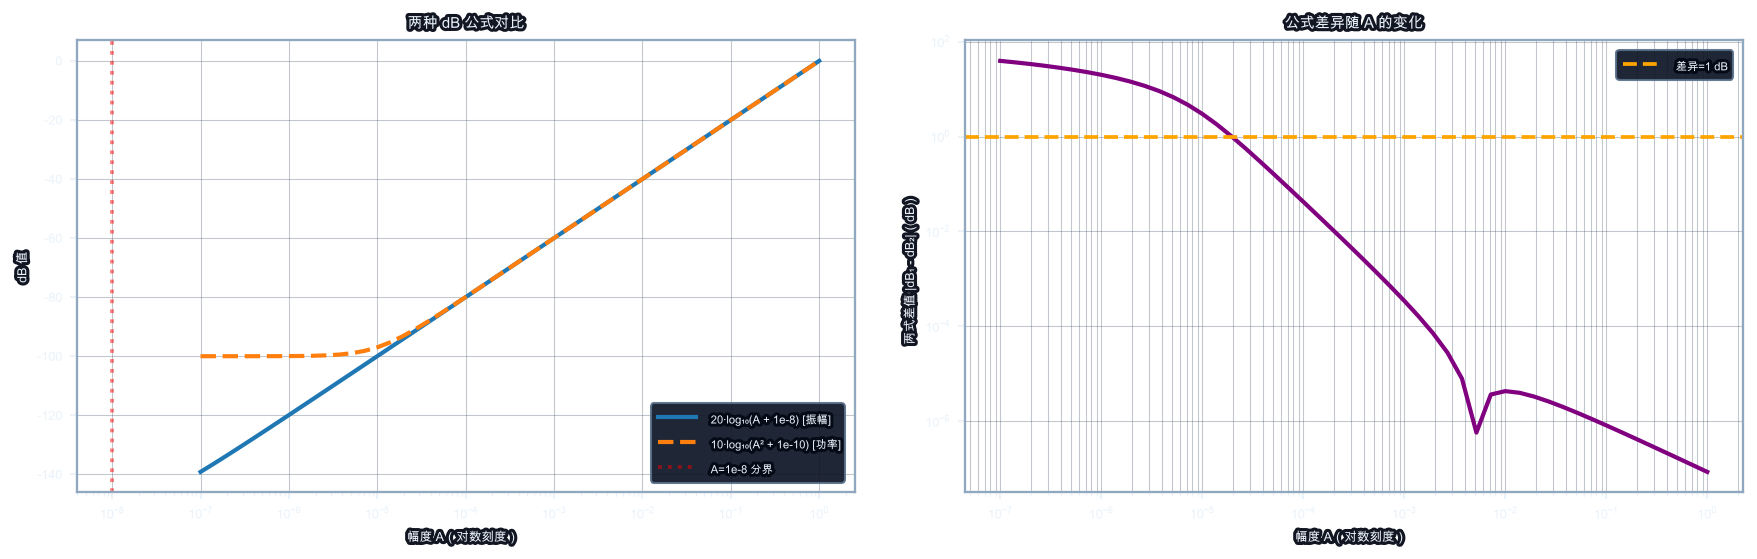

In [4]:
# 演示：两种 dB 形式的等价性与差异（回答"什么时候近似相等"）
import numpy as np

# 构造 A 值从 1e-7 到 1 的范围，展示两种形式的差异
A_vals = np.logspace(-7, 0, 50)  # 从 1e-7 到 1

# 方法1：振幅形式，ε = 1e-8
dB_amp = 20 * np.log10(A_vals + 1e-8)

# 方法2：功率形式，ε = 1e-10
P_vals = A_vals ** 2
dB_pow = 10 * np.log10(P_vals + 1e-10)

# 两者差异
diff = np.abs(dB_amp - dB_pow)

# 画图展示
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# 左图：两条曲线对比
ax1.semilogx(A_vals, dB_amp, label="20·log₁₀(A + 1e-8) [振幅]", linewidth=2)
ax1.semilogx(A_vals, dB_pow, label="10·log₁₀(A² + 1e-10) [功率]", linewidth=2, linestyle="--")
ax1.axvline(1e-8, color='r', linestyle=':', alpha=0.5, label="A=1e-8 分界")
ax1.set_xlabel("幅度 A（对数刻度）")
ax1.set_ylabel("dB 值")
ax1.set_title("两种 dB 公式对比")
ax1.legend()
ax1.grid(True, alpha=0.3)

# 右图：差异幅度
ax2.loglog(A_vals, diff, linewidth=2, color='purple')
ax2.axhline(1, color='orange', linestyle='--', label="差异=1 dB")
ax2.set_xlabel("幅度 A（对数刻度）")
ax2.set_ylabel("两式差值 |dB₁ - dB₂|（dB）")
ax2.set_title("公式差异随 A 的变化")
ax2.legend()
ax2.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

# 数值表格：关键点处的值
print("\n两种形式在关键幅度处的值对比：")
print("=" * 70)
print(f"{'A 幅度':<12} {'20·log(A+1e-8)':<20} {'10·log(A²+1e-10)':<20} {'差值':<10}")
print("=" * 70)
for A in [1, 0.1, 0.01, 1e-4, 1e-6, 1e-8]:
    db1 = 20 * np.log10(A + 1e-8)
    db2 = 10 * np.log10(A**2 + 1e-10)
    diff_val = abs(db1 - db2)
    print(f"{A:<12.0e} {db1:<20.2f} {db2:<20.2f} {diff_val:<10.3f}")

print("\n结论：")
print("  • 当 A ≥ 0.01（强信号）：两式几乎相同（差异 < 0.1 dB）")
print("  • 当 A ≈ 1e-8（弱信号）：开始有明显差异（≈ 2~3 dB）")
print("  • 当 A < 1e-8（极弱信号）：完全由 ε 主导，差异趋于常数")
print("  • 实际应用中，A ≥ 1e-4 时可视为“等价”")

观察效果：
  ε=1e-15：噪声底=-300 dB，静音区有花纹（过度细化）
  ε=1e-10：噪声底=-160 dB，干净可用（推荐）
  ε=1e-8：噪声底=-160 dB，同上（推荐）
  ε=1e-5：噪声底=-100 dB，弱音略显 compressed

两个推荐值对应相同的噪声底 -160 dB，只是形式不同。


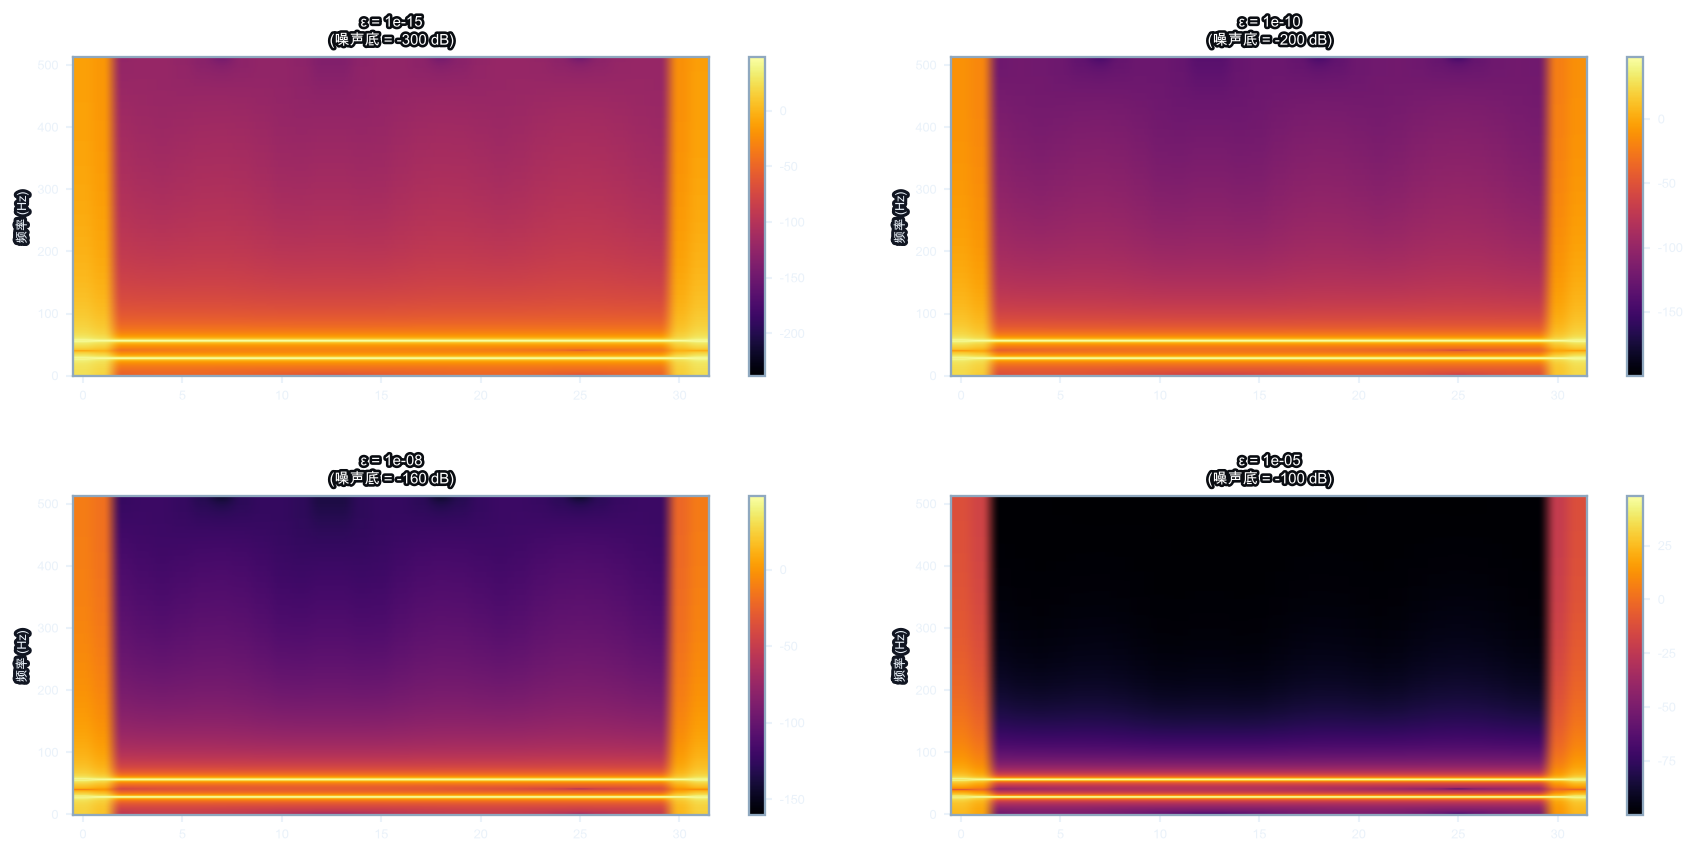

In [5]:
# 演示：不同 ε 对 dB 谱的噪声底影响
SR = 16000
x = sine(440, duration=0.5, sample_rate=SR) + sine(880, duration=0.5, sample_rate=SR)

S = stft(x, n_fft=1024, hop_length=256)
A = np.abs(S)

# 计算不同 ε 的 dB 谱（振幅形式）
eps_list = [1e-15, 1e-10, 1e-8, 1e-5]
dB_list = [20 * np.log10(A + eps) for eps in eps_list]

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
axes = axes.flatten()

for ax, dB, eps in zip(axes, dB_list, eps_list):
    im = ax.imshow(dB.T, origin="lower", aspect="auto", cmap="inferno")
    noise_floor_dB = 20 * np.log10(eps)
    ax.set_title(f"ε = {eps:.0e}\n(噪声底 = {noise_floor_dB:.0f} dB)")
    ax.set_ylabel("频率 (Hz)")
    fig.colorbar(im, ax=ax)

axes[0].set_ylabel("频率 (Hz)")
axes[2].set_ylabel("频率 (Hz)")
plt.tight_layout()
plt.show()

print("观察效果：")
print(f"  ε=1e-15：噪声底=-300 dB，静音区有花纹（过度细化）")
print(f"  ε=1e-10：噪声底=-160 dB，干净可用（推荐）")
print(f"  ε=1e-8：噪声底=-160 dB，同上（推荐）")
print(f"  ε=1e-5：噪声底=-100 dB，弱音略显 compressed")
print("\n两个推荐值对应相同的噪声底 -160 dB，只是形式不同。")

### STFT 帧数公式推导：为什么是 `1 + (N - win_len) // hop`？

当对长度为 N 的信号做 STFT 时，需要计算能放置多少帧（每帧包含 `win_len` 个样本，相邻帧间隔 `hop` 个样本）。

**推导过程**：
1. 第 0 帧从样本 0 开始
2. 第 1 帧从样本 hop 开始
3. 第 m 帧从样本 `m·hop` 开始

**最后一帧的限制**：最后一帧要完整地覆盖 `win_len` 个样本，所以最后一帧的**起始位置**不能超过 `N - win_len`（这样才能读到样本 `N-1`）。

因此最后一帧的帧号 `m_max` 满足：
$$m_{\max} \cdot \text{hop} \leq N - \text{win\_len}$$

$$m_{\max} \leq \frac{N - \text{win\_len}}{\text{hop}}$$

由于 `m_max` 必须是整数，取整：
$$m_{\max} = \left\lfloor \frac{N - \text{win\_len}}{\text{hop}} \right\rfloor = (N - \text{win\_len}) \text{ // } \text{hop}$$

**总帧数** = 最大帧号 + 1（因为第 0 帧也算）：
$$n_{\text{frames}} = m_{\max} + 1 = 1 + \left\lfloor \frac{N - \text{win\_len}}{\text{hop}} \right\rfloor = 1 + (N - \text{win\_len}) \text{ // } \text{hop}$$

**具体例子**：
- `N = 8000`（1 秒 @ 8 kHz），`win_len = 256`，`hop = 128`
- $N - \text{win\_len} = 8000 - 256 = 7744$
- $(7744) \text{ // } 128 = 60$
- $n_{\text{frames}} = 1 + 60 = 61$ 帧
- 验证：最后一帧起始于样本 $60 \times 128 = 7680$，结束于样本 $7680 + 256 - 1 = 7935 < 8000$ ✓

**注意**：这个公式假设窗口完全包含在信号长度内（不考虑 padding）。如果启用 `center=True`（L44 的 STFT 会做），实际帧数可能略有不同，但原理相同。

## 概念 2：`imshow` 的关键参数

`plt.imshow` 默认把矩阵第 0 行画在顶部（图像坐标系），但频率图习惯低频在下，所以必须设：

```
origin="lower"   # 第 0 行（DC / 0 Hz）在底部
aspect="auto"    # 不强制正方形像素，适配任意时频比例
extent=[t_min, t_max, f_min, f_max]  # 让坐标轴显示真实单位
```

`extent` 的顺序是 `[x_left, x_right, y_bottom, y_top]`，对应
`[0, duration_s, 0, sr/2]`。
`sr/2` 是奈奎斯特频率，即 STFT 能表示的最高频率。

### imshow 的坐标系与转置的映射关系（直观理解）

STFT 输出矩阵 `S` 的形状是 `(n_frames, n_fft//2+1)`，其中：
- **行（第 0 维）**= 时间（帧序号）
- **列（第 1 维）**= 频率（频率 bin）

但 `plt.imshow` 的默认行为是：
- **行（第 0 维）** → **纵轴（y 轴）**
- **列（第 1 维）** → **横轴（x 轴）**

**不转置时会发生什么？**

```
STFT 矩阵 (63, 257)
     行=时间，列=频率
          ↓ imshow
     纵轴=时间（上下），横轴=频率（左右）
     ❌ 这反了！我们要频率在纵轴！
```

**转置 `.T` 后**：

```
转置矩阵 (257, 63)
     行=频率，列=时间
          ↓ imshow
     纵轴=频率（上下），横轴=时间（左右）
     ✓ 正确！
```

**origin 参数的作用**：

`imshow` 默认用**图像坐标系**（第 0 行在顶部），但频率图习惯**笛卡尔坐标系**（y=0 在底部）。

转置后矩阵的第 0 行代表频率 0 Hz（DC，最低频）。为了让低频显示在图的下方（符合直觉），必须用 `origin="lower"`。

```
origin="upper" (默认)          origin="lower" (设置后)
   row 0: 0 Hz ────────────       row 256: 8000 Hz ────
   row 1: 31.25 Hz                row 255: 7968.75 Hz
   ...                             ...
   row 256: 8000 Hz ════════       row 0: 0 Hz ════════
   ↑                               ↑
   低频在上面（奇怪！）             低频在下面（符合直觉）
```

**结合 extent 的完整效果**：

```python
plt.imshow(S.T, origin="lower", aspect="auto",
           extent=[0, duration, 0, sr/2])
```

- `.T`：让频率在纵轴
- `origin="lower"`：让 0 Hz 在下方
- `extent=[0, duration, 0, sr/2]`：标上真实的秒数和赫兹刻度


### ✨ extent 参数详解：为什么是这个顺序？

`extent=[x_left, x_right, y_bottom, y_top]` 看起来奇怪是因为顺序与常见的 `[x_min, x_max, y_min, y_max]` 不同。

**matplotlib 的文档约定**（不是 NumPy 的，是 imshow 特有的）：

- `extent[0]` = x 轴左边界（最小时间）= 0
- `extent[1]` = x 轴右边界（最大时间）= 信号总时长 duration_s
- `extent[2]` = y 轴下边界（最小频率，因为 origin='lower'）= 0 Hz
- `extent[3]` = y 轴上边界（最大频率）= sr/2（奈奎斯特频率）

**为什么 y 轴是"下→上"而不是"上→下"？**

因为设置了 `origin='lower'`，imshow 会反转 y 轴方向。所以在指定坐标范围时，也要用"下→上"的顺序来对应实际的轴方向。

**具体值的来源**：
- `duration = len(x) / sr`：信号总采样点数除以采样率 = 秒数
- `sr / 2`：奈奎斯特频率。STFT 用 real-valued FFT，只输出 0 到 sr/2 的频率（高于 sr/2 的频率无法用整数采样率表示）

**与矩阵 shape 的对应**：
- 矩阵 shape 是 `(n_frames, n_fft//2+1)`（转置前）
- `n_frames` 不直接用，而是通过 `duration` 和采样率计算得出
- `n_fft//2+1 = n_bins` 不直接用，而是通过 `sr/2` 和分辨率计算得出

这样做的好处是：即使你改变 `hop` 或 `n_fft`，只要信号长度和采样率不变，`extent` 也不变，图形自动缩放。

### 频率分辨率与时间分辨率的权衡（用具体数字理解）

**频率分辨率** = 频谱的最小可分辨频率间隔，定义为：
$$\Delta f = \frac{sr}{n\_fft} \quad [\text{Hz/bin}]$$

**时间分辨率** = 时间轴的最小可分辨时间间隔，定义为：
$$\Delta t = \frac{\text{hop\_length}}{sr} \quad [\text{秒/帧}]$$

**具体例子**（sr=8000 Hz）：

| 配置 | win_len | hop | n_fft | Δf (Hz/bin) | Δt (ms/帧) | 用途 |
|------|---------|-----|-------|-------------|-----------|------|
| 高时间分辨 | 256 | 64 | 256 | **31.25** | **8** | 检测快速变化的事件（拨弦、击键） |
| 均衡 | 512 | 256 | 512 | **15.63** | **32** | 一般音频分析 |
| 高频率分辨 | 2048 | 512 | 2048 | **3.91** | **64** | 精确区分接近的音高（440Hz vs 445Hz） |

**实际判断能否分辨**：

440 Hz 和 445 Hz 两个纯音。它们在多宽的 bin 中能分开？

- **Δf = 31.25 Hz**：两个频率都落在同一个 bin 内（bin14 = 437.5 Hz，bin15 = 468.75 Hz）→ **无法分辨**
- **Δf = 15.63 Hz**：440 Hz 落在 bin28 (437.5 Hz)，445 Hz 落在 bin29 (453.125 Hz) → **勉强分辨**
- **Δf = 3.91 Hz**：440 Hz 落在 bin112 (438.5 Hz)，445 Hz 落在 bin114 (445.3 Hz) → **清晰分辨**

**为什么 Δf 小时有优势？**

$$n_{\text{fft}} = \Delta f_{\text{desired}}^{-1} \times sr$$

若要 Δf = 3.91 Hz，需要 `n_fft = 8000 / 3.91 ≈ 2048`。

但 `n_fft` 越大，单帧覆盖的时间越长：帧长 = `n_fft / sr = 2048 / 8000 = 0.256` 秒，时间分辨率随之下降。

这正是下表总结的**时频权衡**。

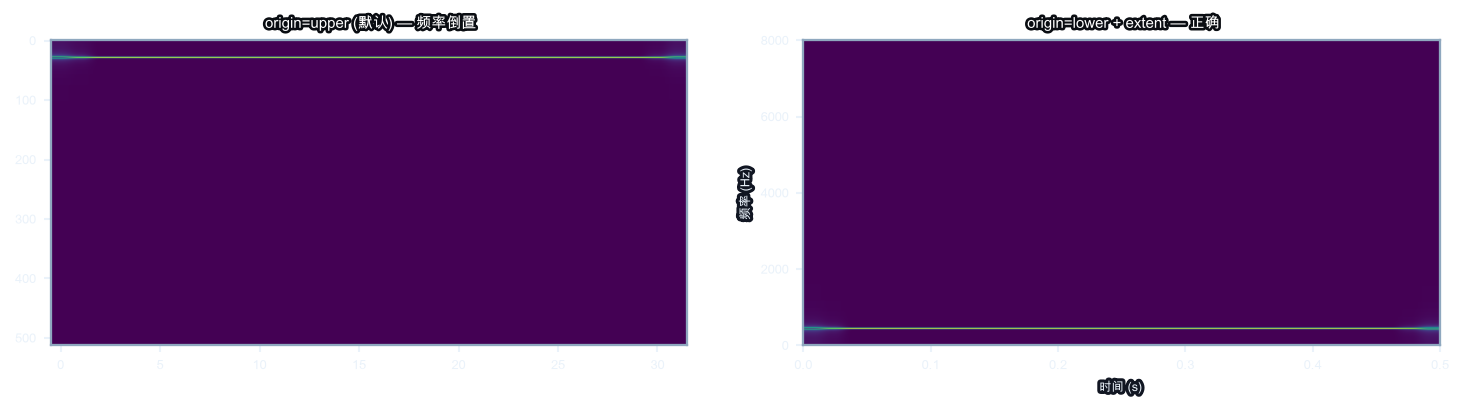

In [6]:
# 演示：origin 和 aspect 对图形的影响
SR = 16000
dur = 0.5
x = sine(440, duration=dur, sample_rate=SR)
S = stft(x, n_fft=1024, hop_length=256)
A = np.abs(S).T   # 转置：(频率箱, 帧数) → imshow 行=频率, 列=时间

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

axes[0].imshow(A, aspect="auto")
axes[0].set_title("origin=upper (默认) — 频率倒置")

axes[1].imshow(A, origin="lower", aspect="auto",
               extent=[0, dur, 0, SR/2])
axes[1].set_title("origin=lower + extent — 正确")
axes[1].set_xlabel("时间 (s)")
axes[1].set_ylabel("频率 (Hz)")

plt.tight_layout()
plt.show()

## 概念 3：时间轴与频率轴的精确计算

**频率轴**：rfft 输出 `n_fft//2 + 1` 个箱，箱 `k` 对应频率：

```
f[k] = k * sr / n_fft      k = 0, 1, ..., n_fft//2
```

即 `f = np.arange(n_fft//2 + 1) * sr / n_fft`。

**时间轴**：第 `t` 帧的中心样本位于 `t * hop_length`（启用 `center=True` 时已经对齐），
换算成秒：

```
t[i] = i * hop_length / sr     i = 0, 1, ..., n_frames-1
```

`extent` 传入的只是边界，用 `[0, n_frames*hop/sr, 0, (n_fft//2)*sr/n_fft]` 足够精确。

In [7]:
# 演示：手动计算轴刻度
SR = 16000
N_FFT = 1024
HOP = 256

f_bins = np.arange(N_FFT // 2 + 1) * SR / N_FFT   # 513 个频率
print(f"频率箱数: {len(f_bins)}")
print(f"频率分辨率: {SR/N_FFT:.2f} Hz/箱")
print(f"最高频率: {f_bins[-1]:.0f} Hz  (= SR/2 = {SR//2} Hz)")

x = sine(440, duration=1.0, sample_rate=SR)
S = stft(x, n_fft=N_FFT, hop_length=HOP)
n_frames = S.shape[0]
t_bins = np.arange(n_frames) * HOP / SR
print(f"\n帧数: {n_frames}")
print(f"时间分辨率: {HOP/SR*1000:.1f} ms/帧")
print(f"总时长覆盖: {t_bins[-1]:.3f} s")

频率箱数: 513
频率分辨率: 15.62 Hz/箱
最高频率: 8000 Hz  (= SR/2 = 8000 Hz)

帧数: 63
时间分辨率: 16.0 ms/帧
总时长覆盖: 0.992 s


## 1. ✏️ 实现 `plot_spectrogram(x, sr, win_len=1024, hop=256)`

**五步流程**：

| 步骤 | 代码 | 说明 |
|---|---|---|
| 1 | `S = my_stft(x, win_len, hop)` 或 `stft(x,...)` | 获取复数 STFT 矩阵 |
| 2 | `power = np.abs(S) ** 2` | 功率谱 |
| 3 | `db = 10 * np.log10(power + 1e-9)` | dB 谱（加 ε 防 log(0)） |
| 4 | `plt.imshow(db.T, origin='lower', aspect='auto', ...)` | `.T`：让频率在纵轴；`origin='lower'`：低频在下 |
| 5 | 计算时间/频率轴，设置 xlabel/ylabel | `t = np.arange(n_frames)*hop/sr`，`f = k*sr/win_len` |

**验收标准**：
- 440 Hz + 880 Hz 双音信号 → 两条清晰水平线
- `db.shape == (n_frames, win_len//2+1)`（转置前）
- 函数返回 `db` 数组（供数值验证）

In [8]:
def plot_spectrogram(x, sr, win_len=1024, hop=256):
    """把信号画成 dB 幅度频谱图。返回 dB 矩阵以便数值验证。

    Parameters
    ----------
    x       : 1-D float array，时域信号
    sr      : 采样率（Hz）
    win_len : FFT 窗长（样本数）
    hop     : 帧移（样本数）

    Returns
    -------
    dB : ndarray, shape (n_fft//2+1, n_frames)
    """
    raise NotImplementedError("请完成 TODO 步骤 1–3，然后删除此行")  # ← 删除此行再填写实现

    # ✏️ TODO 步骤 1：调用 stft() 得到复数矩阵 S，形状 (n_frames, win_len//2+1)
    S = ...

    # ✏️ TODO 步骤 2：np.abs(S).T 得到 (频率, 时间) 幅度矩阵，再转 dB
    # 注意：此处使用 20*log10(A + 1e-8)（振幅形式），与 Aurora power_to_db 的
    # 10*log10(P + 1e-10)（功率形式）近似等价，但 eps 楼层略有差异（见 Cell 3）
    A = ...
    dB = ...

    dur = len(x) / sr

    # ✏️ TODO 步骤 3：imshow + colorbar + 轴标签（origin="lower", aspect="auto"）
    fig, ax = plt.subplots(figsize=(10, 4))
    ...

    return dB  # 返回 dB 矩阵供外部验证


In [9]:
# 目视验证：两条水平线是否清晰
SR = 16000
x_test = sine(440, duration=1.0, sample_rate=SR) + sine(880, duration=1.0, sample_rate=SR)

try:
    student_dB = plot_spectrogram(x_test, SR)
    if student_dB is not None and hasattr(student_dB, "shape"):
        assert student_dB.shape[0] == 513, (
            f"频率箱数应为 513，实际 {student_dB.shape[0]}"
        )
        assert student_dB.max() > -20, (
            f"最大 dB 值 {student_dB.max():.1f} dB 过低，检查幅度计算"
        )
        print(f"✅ plot_spectrogram 验证通过：shape={student_dB.shape}，"
              f"dB.max()={student_dB.max():.1f} dB")
    else:
        print("⚠️  plot_spectrogram 返回 None，请确保函数末尾有 return dB")
except (NotImplementedError, TypeError):
    print("⬜ 未实现：删除 raise NotImplementedError 行并填写 TODO")

# 数值检查（参考实现，用于 Cell 13 的色阶范围）
# 起别名 _stft：这里的 stft 只是想和上面 Cell cell-l45-0451 导入、
# 你在 plot_spectrogram 里调用的 stft() 区分开——两者其实是同一个函数，
# 起别名纯粹是为了在这段"参考答案"代码里不和你自己的实现同名、便于对照验证，
# 不是要换一个不同的实现。
from aurora.audio.stft import stft as _stft
S_ref = _stft(x_test, n_fft=1024, hop_length=256)
A_ref = np.abs(S_ref).T
dB_ref = 20 * np.log10(A_ref + 1e-8)

assert dB_ref.max() > -20, "亮线 dB 值过低，检查幅度计算"
assert dB_ref.shape[0] == 513, f"频率箱数应为 513，实际 {dB_ref.shape[0]}"
print(f"✅ 参考实现：shape={dB_ref.shape}，dB_ref.max()={dB_ref.max():.1f} dB")
print("   （440 Hz 和 880 Hz 处应有清晰水平亮线）")


⬜ 未实现：删除 raise NotImplementedError 行并填写 TODO
✅ 参考实现：shape=(513, 63)，dB_ref.max()=48.0 dB
   （440 Hz 和 880 Hz 处应有清晰水平亮线）


## 参数实验：改变 win_len 和 hop 观察时频分辨率权衡

`win_len`（窗长）和 `hop`（帧移）控制**时频分辨率的权衡**：

| 参数 | 变大时 | 代价 |
|------|--------|------|
| `win_len` 增大 | 频率分辨率（frequency resolution）提高（箱更窄） | 时间分辨率（time resolution）下降（帧覆盖更长） |
| `hop` 减小 | 时间分辨率提高（帧更密） | 计算量增加 |

**预期现象**：
- `win_len=256, hop=64`：水平线变粗（频率模糊），时间轴很密
- `win_len=2048, hop=512`：水平线很细（频率清晰），瞬态事件变模糊

✅ 观察三列图中亮线宽度的变化


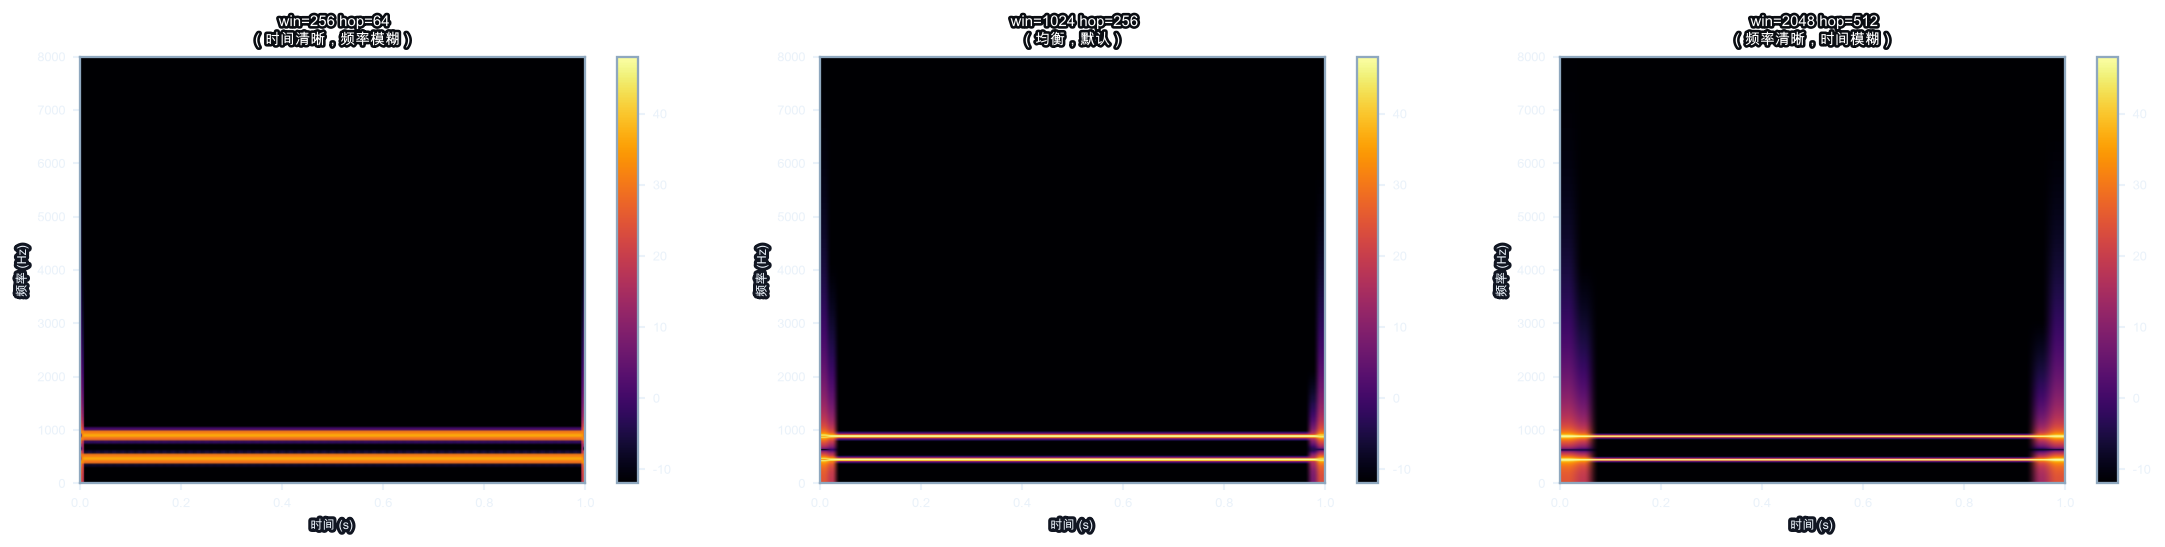

In [10]:
SR = 16000
x_exp = sine(440, duration=1.0, sample_rate=SR) + sine(880, duration=1.0, sample_rate=SR)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

configs = [
    (256,  64,  "win=256 hop=64\n（时间清晰，频率模糊）"),
    (1024, 256, "win=1024 hop=256\n（均衡，默认）"),
    (2048, 512, "win=2048 hop=512\n（频率清晰，时间模糊）"),
]

for ax, (win, hop, title) in zip(axes, configs):
    S = stft(x_exp, n_fft=win, hop_length=hop)
    A = np.abs(S).T
    dB = 20 * np.log10(A + 1e-8)
    dur = len(x_exp) / SR
    im = ax.imshow(dB, origin="lower", aspect="auto",
                   extent=[0, dur, 0, SR/2], cmap="inferno",
                   vmin=dB_ref.max()-60, vmax=dB_ref.max())
    ax.set_title(title)
    ax.set_xlabel("时间 (s)")
    ax.set_ylabel("频率 (Hz)")
    fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()
print("✅ 观察三列图中亮线宽度的变化")

## 本课收束

本课实现了 `plot_spectrogram()`，输出以 dB 为单位的时频热力图。
核心操作链是 `stft → np.abs → 平方/对数 → imshow`，其中 `origin="lower"` 和 `extent` 决定了时频轴能不能对齐。
你在这里写下的处理方式，会直接对应到 Aurora 的 `aurora.audio.stft.magnitude_spectrogram()` 和 `aurora.audio.mel.power_to_db()`。下一课（L46）会在这张频谱图上继续往前，搭出 Mel 滤波器组。

## Aurora 连接验证 — magnitude_spectrogram 与 power_to_db

Aurora 封装的 `magnitude_spectrogram()` 和 `power_to_db()` 与本课手写链等价，但使用功率形式：

| 形式 | 公式 | eps | dB 底 |
|------|------|-----|-------|
| 振幅形式（本课练习） | `20·log10(A + 1e-8)` | 1e-8 | ≈ −160 dB |
| 功率形式（Aurora API） | `10·log10(P + 1e-10)` | 1e-10 | ≈ −100 dB |

两者对 A≥0.01 的信号数值近似相等；仅在接近静音（A≈0）时噪声底不同。
下方代码验证两者在 440+880 Hz 测试信号上的最大差异 < 1 dB。

In [11]:
# Aurora 连接：验证 magnitude_spectrogram / power_to_db 与手写链的一致性
SR = 16000
x_verify = sine(440, duration=0.5, sample_rate=SR) + sine(880, duration=0.5, sample_rate=SR)

# 手写链（振幅形式，本课练习公式）
S_hand = stft(x_verify, n_fft=1024, hop_length=256)
A_hand = np.abs(S_hand).T
dB_hand = 20 * np.log10(A_hand + 1e-8)

# Aurora API（功率形式）
dB_aurora = power_to_db(np.abs(S_hand).T ** 2)

# 只在两者都未被压平的强信号区比较：power_to_db 的 top_db=80 会把
# 谱底截断在 (峰值 - 80) dB ≈ -32 dB，所以比较阈值取 -30 dB 以避开地板
mask = dB_hand > -30
diff = np.abs(dB_hand[mask] - dB_aurora[mask])
print(f"手写链 dB 范围: [{dB_hand.min():.1f}, {dB_hand.max():.1f}] dB")
print(f"Aurora dB 范围: [{dB_aurora.min():.1f}, {dB_aurora.max():.1f}] dB")
print(f"信号区域最大差异: {diff.max():.2f} dB（< 1 dB 即视为等价）")
assert diff.max() < 1.0, f"差异过大: {diff.max():.2f} dB"
print("✅ Aurora API 与手写链在强信号区等价（top_db 地板与 eps 仅影响弱信号/静音）")

# 同时演示 magnitude_spectrogram 直接调用（注意：返回线性 |STFT|，非 dB）
mag_direct = magnitude_spectrogram(x_verify)
print(f"magnitude_spectrogram() 输出 shape: {mag_direct.shape}（线性幅度）")
print("✅ magnitude_spectrogram 提供 |STFT|，再套 power_to_db 即得本课的 dB 链")

手写链 dB 范围: [-160.0, 48.0] dB
Aurora dB 范围: [-32.0, 48.0] dB
信号区域最大差异: 0.00 dB（< 1 dB 即视为等价）
✅ Aurora API 与手写链在强信号区等价（top_db 地板与 eps 仅影响弱信号/静音）
magnitude_spectrogram() 输出 shape: (32, 513)（线性幅度）
✅ magnitude_spectrogram 提供 |STFT|，再套 power_to_db 即得本课的 dB 链


## ✏️ 白板挑战：声谱图手算（目标 10 分钟）

盖上屏幕，纸上作答：

**问 1**：`sr=8000, win_len=256, hop=128, duration=1.0s`：
- 总采样点 N = sr × duration = ?
- n_frames = 1 + (N - win_len) // hop = ?
- 频谱图输出 shape（转置前）= ?

**问 2**：`S[5, 10]` 对应的时间（秒）和频率（Hz）各是多少？  
（`sr=8000, win_len=256, hop=128`）

**问 3**：为什么 `plt.imshow` 需要 `.T`（转置）和 `origin='lower'`？  
（提示：STFT 矩阵行=时间，列=频率；imshow 默认纵轴原点在哪？）

**问 4**：`dB = 10·log₁₀(|S|² + ε)` 中的 ε（如 1e-9）起什么作用？  
当 `|S|=0` 时不加 ε 会发生什么？

**问 5**：440 Hz 在 `win_len=256, sr=8000` 的频谱图中，出现在第几个 bin？  
（`k = round(f / Δf) = round(440 * 256 / 8000) = ?`）

推导完成后运行下面格对答案。

In [12]:
# ✏️ 对答案格
import numpy as np

# 问1：shape 计算
sr1, win1, hop1, dur1 = 8000, 256, 128, 1.0
N1 = int(sr1 * dur1)
n_frames1 = 1 + (N1 - win1) // hop1
n_bins1 = win1 // 2 + 1
assert N1 == 8000
assert n_frames1 == 61
assert n_bins1 == 129
print(f"Q1 ✅  N={N1}, n_frames={n_frames1}, 频谱shape(转置前)=({n_frames1},{n_bins1})")

# 问2：帧/频率对应时间和Hz
m, k = 5, 10
t_sec = m * hop1 / sr1
f_hz  = k * sr1 / win1
assert abs(t_sec - 0.08) < 1e-10
assert f_hz == 312.5
print(f"Q2 ✅  S[5,10] → t={t_sec:.3f}s，f={f_hz:.1f} Hz")

# 问3：imshow 转置和 origin
# 验证：imshow 默认 origin='upper'（行0在顶部）；频谱图需要低频在下
test_mat = np.arange(6).reshape(2, 3)  # 行=时间(2帧)，列=频率(3bin)
# 转置后：行=频率(3)，列=时间(2)；origin='lower'让row0(低频)在下
assert test_mat.T.shape == (3, 2)  # 转置后行=频率
print(f"Q3 ✅  .T 让行=频率（imshow按行画）；origin='lower'让row0低频在下（默认upper→低频在上）")

# 问4：ε 防 log(0)
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    log_zero = np.log10(0.0)
assert np.isinf(log_zero)  # log(0) = -inf
log_eps = 10 * np.log10(0.0 + 1e-9)
assert np.isfinite(log_eps) and log_eps < 0
print(f"Q4 ✅  log₁₀(0)={log_zero}（−inf），加ε→{log_eps:.1f} dB（有限值，代表极弱信号）")

# 问5：440Hz 对应的 bin
f_target, win5, sr5 = 440, 256, 8000
k_bin = round(f_target * win5 / sr5)
f_actual = k_bin * sr5 / win5
assert k_bin == 14
assert f_actual == 437.5
print(f"Q5 ✅  440 Hz → k={k_bin}号bin（精确频率={f_actual} Hz，Δf={sr5/win5:.1f} Hz/bin）")
print("\n🎉 声谱图白板挑战通过！")

Q1 ✅  N=8000, n_frames=61, 频谱shape(转置前)=(61,129)
Q2 ✅  S[5,10] → t=0.080s，f=312.5 Hz
Q3 ✅  .T 让行=频率（imshow按行画）；origin='lower'让row0低频在下（默认upper→低频在上）
Q4 ✅  log₁₀(0)=-inf（−inf），加ε→-90.0 dB（有限值，代表极弱信号）
Q5 ✅  440 Hz → k=14号bin（精确频率=437.5 Hz，Δf=31.2 Hz/bin）

🎉 声谱图白板挑战通过！


In [ ]:
# ✏️ 本课自评
l45_review = {
    "db_formula":              None,  # 记住 dB=10·log₁₀(|S|²+ε)？True/False
    "plot_spectrogram_impl":   None,  # plot_spectrogram 实现，两条线清晰可见？True/False
    "transpose_and_origin":    None,  # 理解为何要 .T 和 origin='lower'？True/False
    "time_freq_axis_calc":     None,  # 能手算 t=m·hop/sr 和 f=k·sr/win？True/False
    "whiteboard_passed":       None,  # 白板挑战纸上推导完成？True/False
    "shape_memo_known":        None,  # 记住 (63,257)→(63,40)→(63,13) 口诀？True/False
}

unfilled = [k for k, v in l45_review.items() if v is None]
assert not unfilled, f'还未填写：{unfilled}'
weak = [k for k, v in l45_review.items() if v is False]
if weak:
    print(f'⚠️  需要加强：{weak}')
else:
    print('✅ L45 全部通关！进入 L46：Mel 滤波器')

---

→ **下一课**　[L46 · Mel 频率尺度](L46_mel.ipynb)

> 下节课将学习 **Mel 频率尺度**：人耳对数感知，mel = 2595·log₁₀(1+f/700)，三角滤波器。